## Question 2 : MARKOV TRANSITION MATRIX

# Markov Processes and Transition Matrices for DNA Sequence Analysis

## 1. Introduction to Markov Processes

A Markov process is a way to model a series of events where the chance of what happens next depends only on what is happening now — not on how you got there.  
This is called the **Markov property** or **memorylessness**.

In simple words:  
Knowing the present is enough. The past does not matter.

## 2. Markov Transition Matrix

A transition matrix shows the chances of moving from one state to another in one step.  
If there are \( n \) states, the matrix \( P \) is \( n \times n \) where:

$$
P(i,j) = \text{chance of going from state } i \text{ to state } j
$$

**Key points:**
- Each row shows the chances of all possible next moves from a state.
- Every value is non-negative.
- Each row adds up to 1 (since something must happen).

## 3. DNA Sequences as Markov Chains

We can model DNA sequences using Markov chains, where:
- **States** are the nucleotides: A, T, G, and C.
- **Transitions** happen when one nucleotide is followed by another.
- A **first-order Markov model** assumes that the next nucleotide depends only on the current one.

## 4. First-Order Markov Model for DNA

For DNA, the transition matrix is \( 4 \times 4 \), showing how likely each nucleotide is to follow another.  
This matters biologically because:
- Some nucleotides prefer to follow others due to chemical properties.
- Codons (sets of three nucleotides) have special roles in making proteins.
- Regulatory regions have certain repeating patterns.

## 5. Example Scenario

Imagine the following DNA sequence:

```
ATGCATGCAATCGTAGCTACGATCGACTGATCGATGCTAGCTAGCTA
```

We can use a first-order Markov chain to model how nucleotides follow each other.

The transition matrix shows:
- \( P(A -> A) \): Chance that A is followed by A.
- \( P(A -> T) \): Chance that A is followed by T.
- And so on for all 16 possible transitions.

## 6. Calculating the Transition Matrix

To build the matrix:
1. **Count** how many times each pair of nucleotides appears next to each other.
2. **Normalize** by dividing the counts for each starting nucleotide so the total for each row is 1.


The function below:  
1. Initializes a 4×4 count matrix for nucleotides A,T,G,C.  
2. Slides along the sequence and **counts** each transition \(n_i \to n_{i+1}\).  
3. **Normalizes** each row so that the probabilities sum to 1.0.  

It returns both the **probability** matrix and the **raw counts**.

In [1]:
def build_markov_transition_matrix(dna_sequence):
    # Initialize counts matrix
    nucleotides = ['A', 'T', 'G', 'C']
    counts = {n1: {n2: 0 for n2 in nucleotides} for n1 in nucleotides}
    
    # Count transitions
    for i in range(len(dna_sequence) - 1):
        current = dna_sequence[i]
        next_nuc = dna_sequence[i + 1]
        counts[current][next_nuc] += 1
    
    # Calculate probabilities
    transition_matrix = {}
    for n1 in nucleotides:
        total = sum(counts[n1].values())
        if total > 0:  
            transition_matrix[n1] = {n2: counts[n1][n2]/total for n2 in nucleotides}
        else:
            transition_matrix[n1] = {n2: 0.0 for n2 in nucleotides}
    
    return transition_matrix, counts

To build the matrix:
1. **Count** how many times each pair of nucleotides appears next to each other.
2. **Normalize** by dividing the counts for each starting nucleotide so the total for each row is 1.

Build_dinucleotide_frequency_model

This function constructs the **joint** dinucleotide frequency matrix:

1. Initializes counts for all 16 pairs (AA, AT, …, CC).  
2. Slides a window of size 2 and **counts** each overlapping pair.  
3. Normalizes by the total number of pairs (\(L-1\)).  

It returns both the **joint probability** dict and the **raw counts**.

In [2]:
def build_dinucleotide_frequency_model(dna_sequence):
    # Initialize counts dictionary
    nucleotides = ['A', 'T', 'G', 'C']
    dinucleotide_counts = {n1 + n2: 0 for n1 in nucleotides for n2 in nucleotides}
    total_dinucleotides = 0
    
    # Count dinucleotides
    for i in range(len(dna_sequence) - 1):
        dinucleotide = dna_sequence[i:i+2]
        if dinucleotide in dinucleotide_counts:
            dinucleotide_counts[dinucleotide] += 1
            total_dinucleotides += 1
    
    # Calculate frequencies
    dinucleotide_frequencies = {dinuc: count/total_dinucleotides 
                              for dinuc, count in dinucleotide_counts.items()}
    
    return dinucleotide_frequencies, dinucleotide_counts

In [3]:
sequence = "ATGCATGCAATCGTAGCTACGATCGACTGATCGATGCTAGCTAGCTA"

# Build both models
markov_matrix, markov_counts = build_markov_transition_matrix(sequence)
dinuc_freqs, dinuc_counts = build_dinucleotide_frequency_model(sequence)

Below we format and print the 4×4 Markov matrix 
$P(\text{next}=j \mid \text{current}=i)$  
- Rows are current nucleotide  
- Columns are next nucleotide  
- Each row sums to 1.


In [4]:
# Print Markov transition matrix
print("Markov Transition Matrix:")
nucleotides = ['A', 'T', 'G', 'C']
print("   " + " ".join(f"{n:>5}" for n in nucleotides))
for n1 in nucleotides:
    row = [f"{markov_matrix[n1][n2]:.3f}" for n2 in nucleotides]
    print(f"{n1}: {' '.join(f'{val:>5}' for val in row)}")

Markov Transition Matrix:
       A     T     G     C
A: 0.083 0.500 0.250 0.167
T: 0.417 0.000 0.333 0.250
G: 0.364 0.091 0.000 0.545
C: 0.182 0.455 0.364 0.000


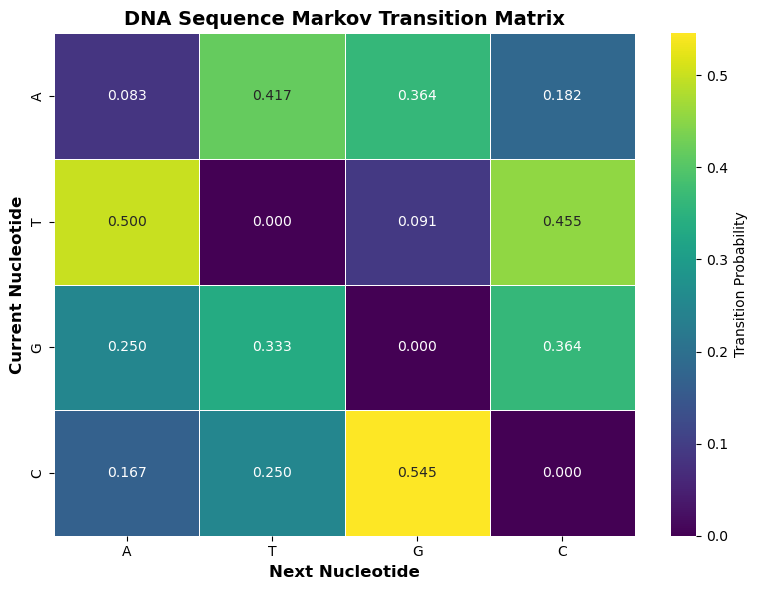

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.DataFrame(markov_matrix, index=nucleotides, columns=nucleotides)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".3f", cmap="viridis", 
            cbar_kws={"label": "Transition Probability"}, linewidths=0.5, linecolor='white')

plt.xlabel("Next Nucleotide", fontsize=12, fontweight="bold")
plt.ylabel("Current Nucleotide", fontsize=12, fontweight="bold")
plt.title("DNA Sequence Markov Transition Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Dinucleotide frequency Model

In [6]:
# Print dinucleotide frequencies in a matrix format for comparison
print("\nDinucleotide Frequency Model:")
print("   " + " ".join(f"{n:>5}" for n in nucleotides))
for n1 in nucleotides:
    row = [f"{dinuc_freqs[n1+n2]:.3f}" for n2 in nucleotides]
    print(f"{n1}: {' '.join(f'{val:>5}' for val in row)}")


Dinucleotide Frequency Model:
       A     T     G     C
A: 0.022 0.130 0.065 0.043
T: 0.109 0.000 0.087 0.065
G: 0.087 0.022 0.000 0.130
C: 0.043 0.109 0.087 0.000


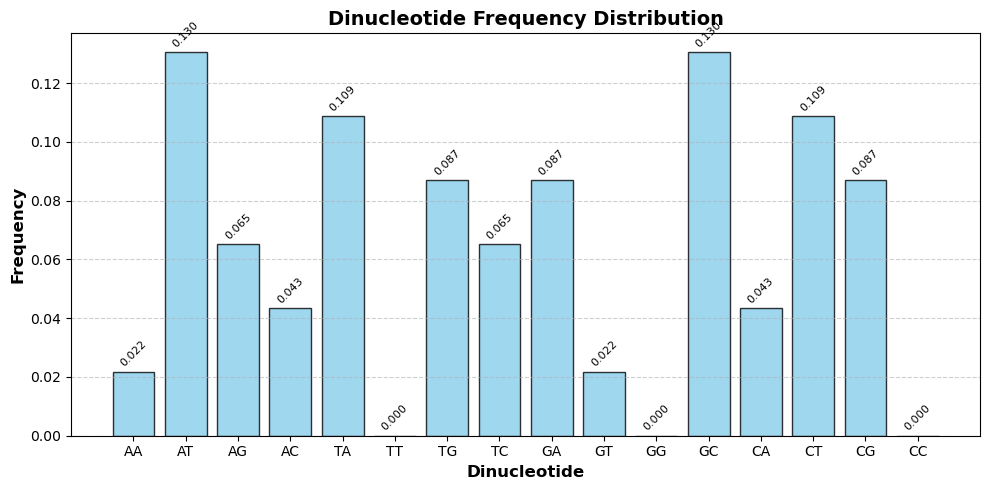

In [7]:
import matplotlib.pyplot as plt

pairs = [n1 + n2 for n1 in nucleotides for n2 in nucleotides]
freqs = [dinuc_freqs[pair] for pair in pairs]

plt.figure(figsize=(10, 5))
bars = plt.bar(pairs, freqs, color="skyblue", alpha=0.8, edgecolor='black')

plt.xlabel("Dinucleotide", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title("Dinucleotide Frequency Distribution", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.001, f"{h:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()


# Comparative Analysis

## Conditional vs. Joint Probabilities

- **Markov Model**: Represents conditional probabilities \( P(B|A) \) — the probability of nucleotide B following nucleotide A.
- **Dinucleotide Model**: Represents joint probabilities \( P(A,B) \) — the probability of observing the dinucleotide AB in the sequence.

## Normalization

- **Markov Model**: Each row sums to 1.0 (or very close due to rounding), as they represent the probability distribution of the next nucleotide given the current one.
- **Dinucleotide Model**: The entire matrix sums to 1.0, representing the frequency distribution of all possible dinucleotides.

## Biological Interpretation

- **Markov Model**: Better captures the sequential dependencies in DNA. For example, it shows that after a C, there's a 50% chance of seeing an A.
- **Dinucleotide Model**: Shows the overall abundance of each dinucleotide. For example, CA and TA together make up 12.2% each of all dinucleotides.
